# Applied Exercise 4 - SVM with Non-Linear Boundaries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [8]:
rng = np.random.default_rng(1)
n = 100
X = rng.normal(size=(n, 2))
radius = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
y = (radius > 0.9).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

print("=" * 60)
print("SIMULATED DATA")
print("=" * 60)
print(f"Observations: {n}")
print(f"Features: 2")
print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

SIMULATED DATA
Observations: 100
Features: 2
Training observations: 70
Test observations: 30


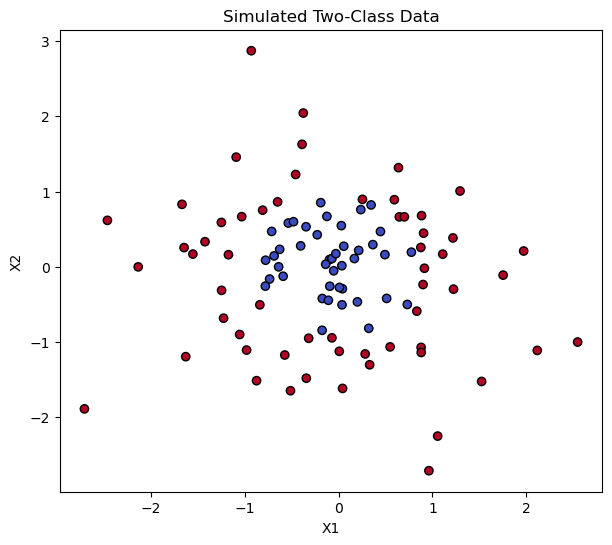

In [4]:
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Simulated Two-Class Data")
plt.show()

In [7]:
models = {"Support Vector Classifier": SVC(kernel="linear", C=1), "Polynomial SVM": SVC(kernel="poly", degree=2, C=1),
          "Radial SVM": SVC(kernel="rbf", C=1, gamma="scale")}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_error = 1 - accuracy_score(y_train, model.predict(X_train))
    test_error = 1 - accuracy_score(y_test, model.predict(X_test))
    results.append([name, train_error, test_error])

results = pd.DataFrame(results, columns=["Model", "Training Error", "Test Error"])

print("=" * 60)
print("SVM PERFORMANCE")
print("=" * 60)
print(results.to_string(index=False))

SVM PERFORMANCE
                    Model  Training Error  Test Error
Support Vector Classifier        0.414286    0.433333
           Polynomial SVM        0.014286    0.066667
               Radial SVM        0.057143    0.066667


The polynomial SVM and radial SVM are able to produce non-linear decision boundaries. Consequently, they achieve substantially lower training error than the linear support vector classifier. The test error provides a better measure of predictive performance because it evaluates the models on observations that were not used during training. In this case both Polynomial SVM of degree 2 and Radial kernel give same test errors and much better than Support Vector Classifier.

# Applied Exercise 5 - Logistic Regression vs SVM with Non-Linear Boundaries

In [9]:
rng = np.random.default_rng(5)
x1 = rng.uniform(size=500) - 0.5
x2 = rng.uniform(size=500) - 0.5
y = (x1**2 - x2**2 > 0).astype(int)

X = pd.DataFrame({"X1": x1, "X2": x2})

print("=" * 60)
print("SIMULATED DATA")
print("=" * 60)
print(f"Observations: {len(X)}")
print(f"Features: {X.shape[1]}")
print(f"Class 0 observations: {(y == 0).sum()}")
print(f"Class 1 observations: {(y == 1).sum()}")

SIMULATED DATA
Observations: 500
Features: 2
Class 0 observations: 247
Class 1 observations: 253


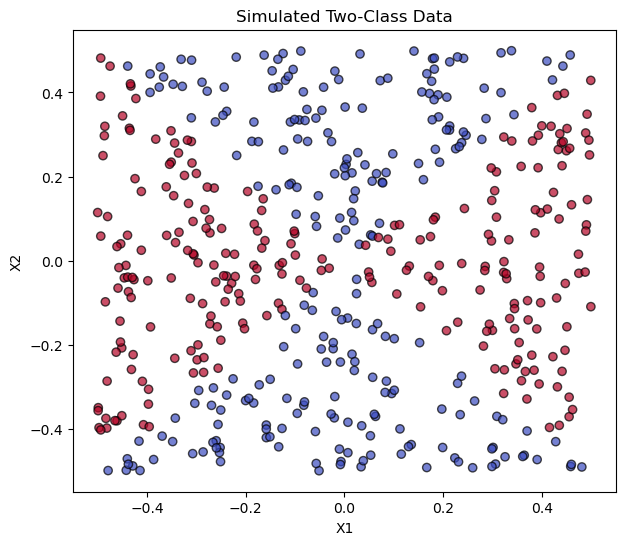

In [12]:
plt.figure(figsize=(7, 6))
plt.scatter(x1, x2, c=y, cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Simulated Two-Class Data")
plt.show()

In [14]:
logistic_linear = LogisticRegression(C=1e6, max_iter=10000)
logistic_linear.fit(X, y)
y_pred_linear = logistic_linear.predict(X)

print("=" * 60)
print("LOGISTIC REGRESSION - LINEAR FEATURES")
print("=" * 60)
print(f"Training accuracy = {accuracy_score(y, y_pred_linear):.4f}")
print(f"Training error = {1 - accuracy_score(y, y_pred_linear):.4f}")

LOGISTIC REGRESSION - LINEAR FEATURES
Training accuracy = 0.4280
Training error = 0.5720


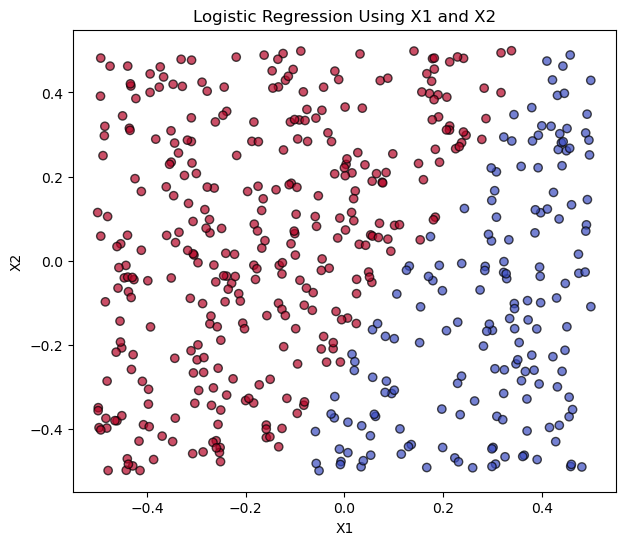

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(x1, x2, c=y_pred_linear, cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Logistic Regression Using X1 and X2")
plt.show()

In [17]:
X_nonlinear = pd.DataFrame({"X1": x1, "X2": x2, "X1_squared": x1**2, "X2_squared": x2**2, "X1_X2": x1*x2})

logistic_nonlinear = LogisticRegression(C=1e6, max_iter=10000)
logistic_nonlinear.fit(X_nonlinear, y)
y_pred_nonlinear = logistic_nonlinear.predict(X_nonlinear)

print("=" * 60)
print("LOGISTIC REGRESSION - NONLINEAR FEATURES")
print("=" * 60)
print(f"Training accuracy = {accuracy_score(y, y_pred_nonlinear):.4f}")
print(f"Training error = {1 - accuracy_score(y, y_pred_nonlinear):.4f}")

LOGISTIC REGRESSION - NONLINEAR FEATURES
Training accuracy = 1.0000
Training error = 0.0000


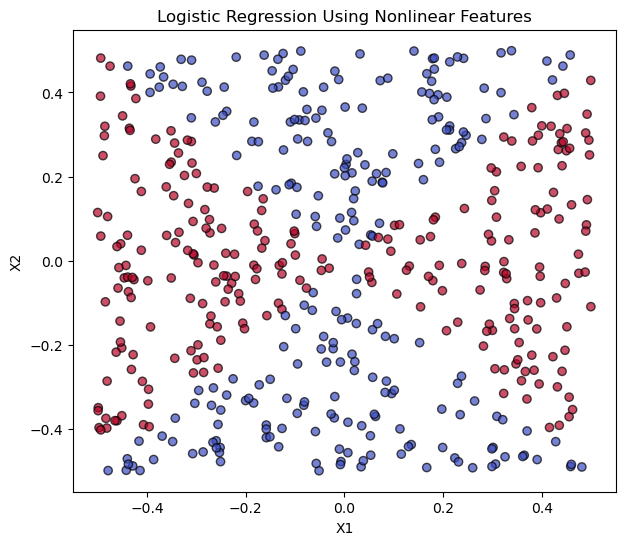

In [18]:
plt.figure(figsize=(7, 6))
plt.scatter(x1, x2, c=y_pred_nonlinear, cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Logistic Regression Using Nonlinear Features")
plt.show()

In [19]:
svc_linear = SVC(kernel="linear", C=1)
svc_linear.fit(X, y)
y_pred_svc = svc_linear.predict(X)

print("=" * 60)
print("SUPPORT VECTOR CLASSIFIER")
print("=" * 60)
print(f"Training accuracy = {accuracy_score(y, y_pred_svc):.4f}")
print(f"Training error = {1 - accuracy_score(y, y_pred_svc):.4f}")

SUPPORT VECTOR CLASSIFIER
Training accuracy = 0.5060
Training error = 0.4940


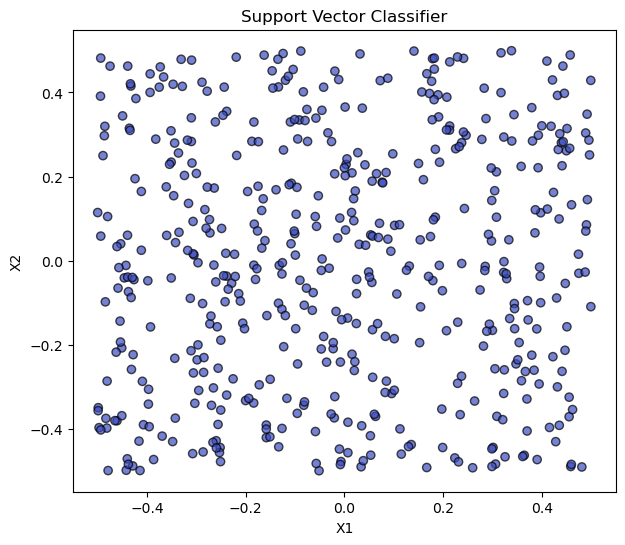

In [21]:
plt.figure(figsize=(7, 6))
plt.scatter(x1, x2, c=y_pred_svc, cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Support Vector Classifier")
plt.show()

In [24]:
svc_rbf = SVC(kernel="rbf", C=1, gamma="scale")
svc_rbf.fit(X, y)
y_pred_rbf = svc_rbf.predict(X)

print("=" * 60)
print("NONLINEAR SVM - RBF (Radial Basis Function) KERNEL")
print("=" * 60)
print(f"Training accuracy = {accuracy_score(y, y_pred_rbf):.4f}")
print(f"Training error = {1 - accuracy_score(y, y_pred_rbf):.4f}")

NONLINEAR SVM - RBF (Radial Basis Function) KERNEL
Training accuracy = 0.9860
Training error = 0.0140


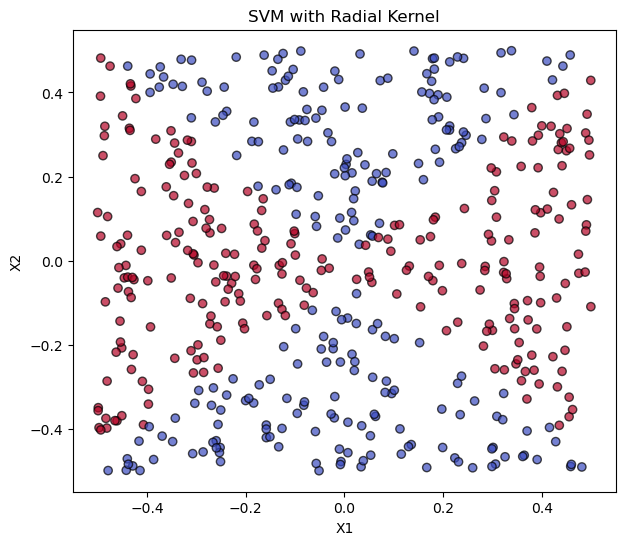

In [23]:
plt.figure(figsize=(7, 6))
plt.scatter(x1, x2, c=y_pred_rbf, cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVM with Radial Kernel")
plt.show()

- Logistic regression using only X1 and X2 produces a linear decision boundary and therefore cannot capture the structure of the data particularly well and has igh training error of 57.2%
- When nonlinear transformations such as X1^2, X2^2, and X1X2 are added as predictors, logistic regression is able to produce a nonlinear decision boundary. The model remains linear in its coefficients, but it is nonlinear in the original predictors. This model execeedingly performs well with 100% accuracy because the original data was generated with very close predictor combinations.
- The linear support vector classifier has the same fundamental limitation because its decision boundary is linear. It has 49.4% training error.
- In contrast, the SVM using a radial kernel can construct a flexible nonlinear decision boundary and is therefore much better suited to this data. It performs well and has 1.4% training error. The reason that SVM has a tiny error rate comapred to Logistic regression is because SVM does few approximations for creating the radial kernel and may have slight misclassifications while logistic has a given a perfect boundary.